In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import shap
from xgboost import plot_importance
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

df = pd.read_csv('../data/processed/data_clean.csv')
categorical_cols = df.select_dtypes(include=['str']).columns

for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

In [2]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Optuna

In [3]:
import optuna


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss",
    }

    threshold = trial.suggest_float("threshold", 0.3, 0.7)

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    return f1_score(y_test, y_pred, pos_label=1)

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=100)

[I 2026-05-03 22:02:21,389] A new study created in memory with name: no-name-9e3a2366-51c3-43a5-8486-58ed0fefdf35
[I 2026-05-03 22:02:23,335] Trial 0 finished with value: 0.568 and parameters: {'n_estimators': 487, 'learning_rate': 0.19063571821788408, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044, 'threshold': 0.5832290311184182}. Best is trial 0 with value: 0.568.
[I 2026-05-03 22:02:23,806] Trial 1 finished with value: 0.6218302094818081 and parameters: {'n_estimators': 310, 'learning_rate': 0.19428287191077892, 'max_depth': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'min_child_weight': 2, 'gamma': 1.5212112147976886, 'reg_alpha': 2.6237821581611893, 'reg_lambda': 2.1597250932105787, 'threshold': 0.41649165607921673}. Best is trial 1 with value: 0.6218302094818081.
[I 2026-05-03 22:02:24,417] T

In [4]:
print("-" * 30)
print("Best Params:", study.best_params)
print("Best F1 Score:", study.best_value)

------------------------------
Best Params: {'n_estimators': 300, 'learning_rate': 0.01790255392911593, 'max_depth': 5, 'subsample': 0.9862791529240323, 'colsample_bytree': 0.6842841767716535, 'min_child_weight': 8, 'gamma': 3.3489292837260547, 'reg_alpha': 0.15637604995409715, 'reg_lambda': 2.923751637446135, 'threshold': 0.5603695164925194}
Best F1 Score: 0.6459489456159823


In [5]:
best = study.best_params.copy()
threshold = best.pop("threshold")

best_model = XGBClassifier(
    **best,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
)
best_model.fit(X_train, y_train)

proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (proba >= threshold).astype(int)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred, normalize='true',))

Test accuracy: 0.7735982966643009
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1035
           1       0.55      0.78      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409

[[0.77198068 0.22801932]
 [0.22192513 0.77807487]]


# Analisis de resultados


Top 10 por weight:
                           feature  weight
19                   charges_ratio   624.0
4                           tenure   580.0
13                  MonthlyCharges   508.0
14                    TotalCharges   500.0
18               avg_monthly_spend   476.0
28  PaymentMethod_Electronic check   161.0
12                PaperlessBilling   160.0
6                   OnlineSecurity   155.0
26               Contract_Two year   135.0
25               Contract_One year   106.0

Top 10 por gain:
                           feature        gain
26               Contract_Two year  228.697449
23     InternetService_Fiber optic  129.873856
25               Contract_One year  119.106758
17                          is_new   72.757881
20         high_value_short_tenure   57.686718
16                   tenure_bucket   40.386955
28  PaymentMethod_Electronic check   34.278412
4                           tenure   29.261208
11                 StreamingMovies   25.887596
24              Int

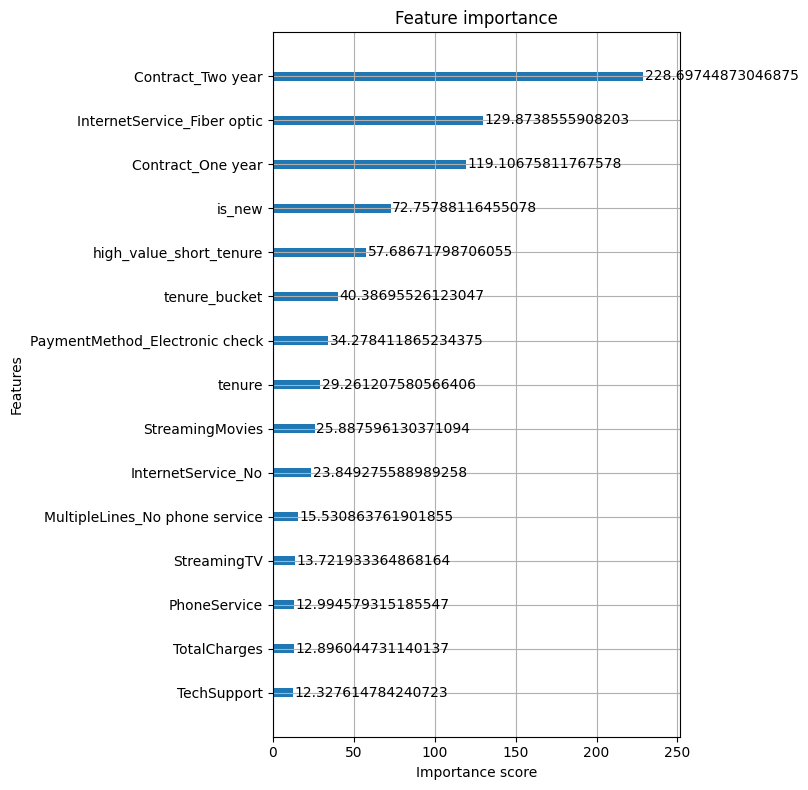

PermutationExplainer explainer: 201it [00:18,  6.21it/s]                         


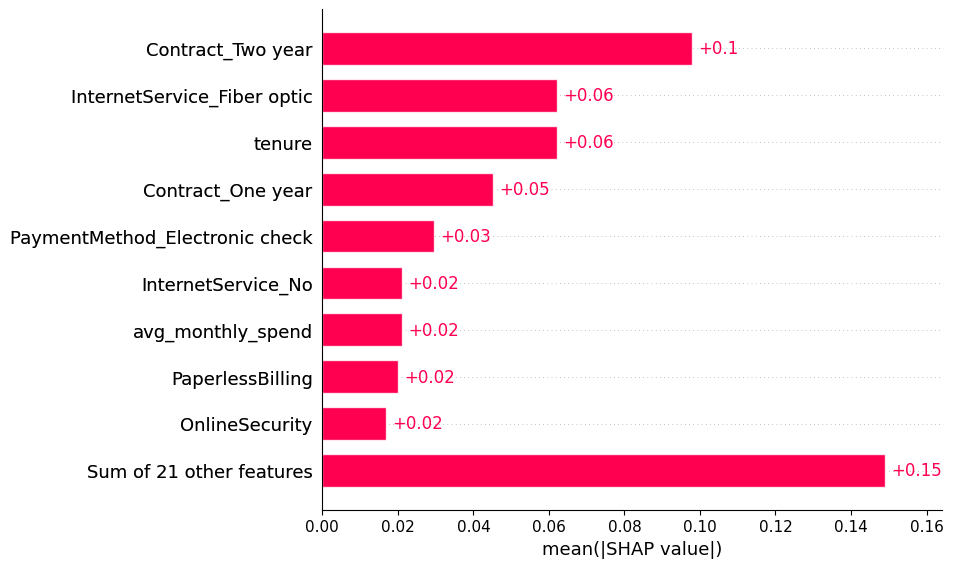

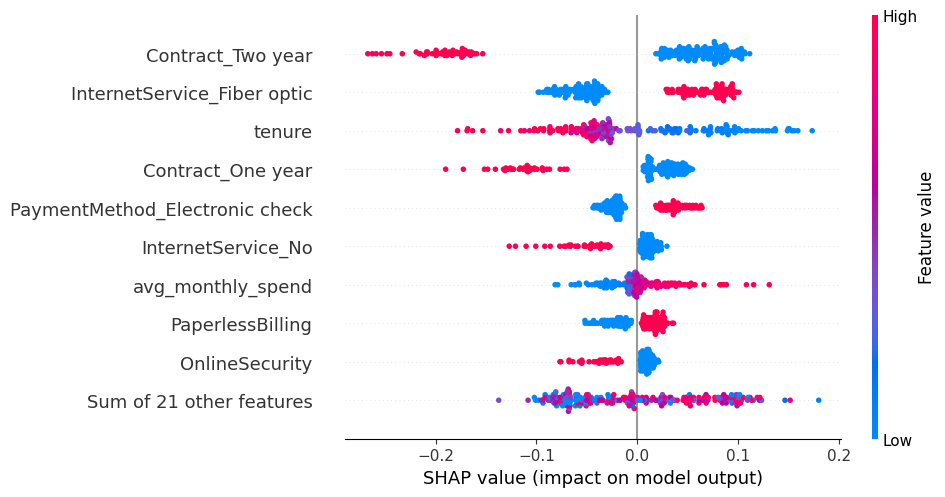

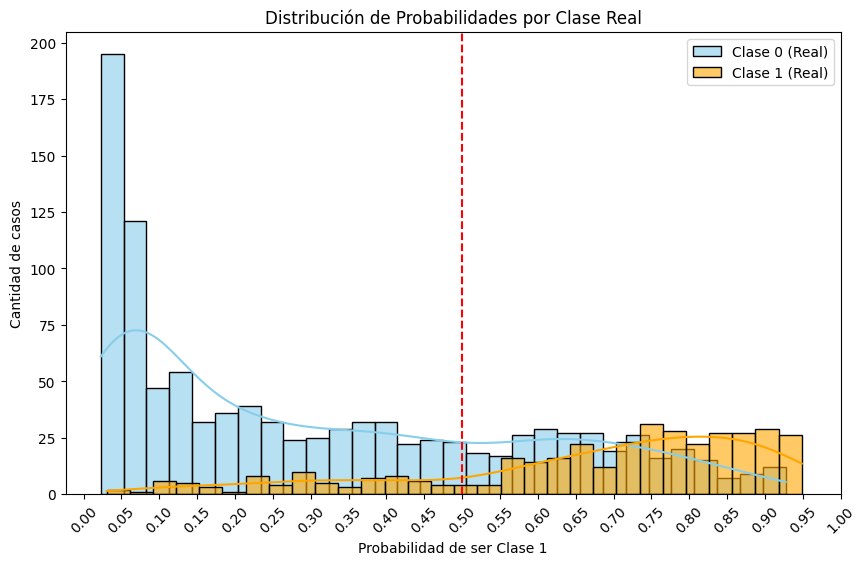

<Figure size 1000x600 with 0 Axes>

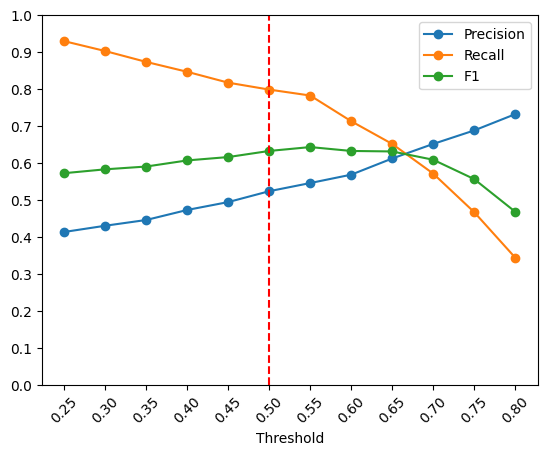

,Threshold,Precision,Recall,F1
6,0.55,0.546642,0.783422,0.643956
5,0.50,0.524561,0.799465,0.633475
7,0.60,0.569296,0.713904,0.633452
8,0.65,0.613065,0.652406,0.632124
4,0.45,0.495146,0.818182,0.616935
9,0.70,0.652439,0.572193,0.609687
3,0.40,0.473842,0.847594,0.607862
2,0.35,0.446721,0.874332,0.591320
1,0.30,0.431122,0.903743,0.583765
0,0.25,0.414286,0.930481,0.573311


In [6]:
# === 1) Importancia nativa con nombres reales ===
try:
    feature_names = best_model[:-1].get_feature_names_out()
except Exception:
    feature_names = None

booster = best_model.get_booster()
if feature_names is not None:
    booster.feature_names = list(feature_names)

for tipo in ["weight", "gain", "cover"]:
    imp = booster.get_score(importance_type=tipo)
    df_imp = pd.DataFrame(imp.items(), columns=["feature", tipo]).sort_values(tipo, ascending=False)
    print(f"\nTop 10 por {tipo}:")
    print(df_imp.head(10))

# === 2) Gráfico ===
fig, ax = plt.subplots(figsize=(8, 8))
plot_importance(booster, max_num_features=15, importance_type="gain", ax=ax)
plt.tight_layout()
plt.show()

# === 3) SHAP usando el pipeline completo ===
sample = X_test.sample(min(200, len(X_test)), random_state=42)

explainer = shap.Explainer(best_model.predict_proba, sample)
shap_values = explainer(sample)

# Para clasificación binaria, tomar la clase positiva (churn=1)
shap_values_pos = shap_values[..., 1]

shap.plots.bar(shap_values_pos)
shap.plots.beeswarm(shap_values_pos)
from sklearn.metrics import precision_score, recall_score, f1_score

proba = best_model.predict_proba(X_test)[:, 1]

results = []
thresholds = np.arange(0.25, 0.85, 0.05)
for threshold in thresholds:
    y_pred_threshold = (proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_threshold, pos_label=1)
    recall = recall_score(y_test, y_pred_threshold, pos_label=1)
    f1 = f1_score(y_test, y_pred_threshold, pos_label=1)
    results.append((threshold, precision, recall, f1))
    
df_threshold = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
df_probs = pd.DataFrame({
    'Real': y_test,
    'Probabilidad': best_model.predict_proba(X_test)[:, 1]
})
plt.figure(figsize=(10, 6))
sns.histplot(data=df_probs[df_probs['Real'] == 0], x='Probabilidad', 
             color='skyblue', label='Clase 0 (Real)', kde=True, bins=30, alpha=0.6)

sns.histplot(data=df_probs[df_probs['Real'] == 1], x='Probabilidad', 
             color='orange', label='Clase 1 (Real)', kde=True, bins=30, alpha=0.6)

plt.axvline(x=0.5, color='red', linestyle='--',)

plt.title('Distribución de Probabilidades por Clase Real')
plt.xlabel('Probabilidad de ser Clase 1')
plt.ylabel('Cantidad de casos')
plt.xticks(np.arange(0, 1.05, 0.05), rotation=45)
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
df_threshold.plot(x='Threshold', y=['Precision', 'Recall', 'F1'], marker='o')
plt.axvline(x=0.5, color='red', linestyle='--',)
plt.xticks(thresholds, rotation=45)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.show()
df_threshold.sort_values('F1', ascending=False)